In [283]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

%config InlineBackend.figure_format = 'svg'

**Data Overview**

In [284]:
weather = pd.read_csv('weatherHistory.csv')

In [285]:
weather.shape

(96453, 12)

In [286]:
weather.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [287]:
weather.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


In [288]:
weather.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(8), str(4)
memory usage: 8.8 MB


In [289]:
weather.isna().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

**Clean Data**

In [290]:
# Drop Null Values as they are a small portion of dataset

weather.dropna(inplace=True)

In [291]:
# Drop Loud Cover column as it is a column of full 0s only

weather = weather.drop('Loud Cover', axis=1)

In [292]:
# Format Date Column as DateTime
#  yyyy-mm-dd time utc

weather['Formatted Date'] = pd.to_datetime(weather['Formatted Date'], utc=True)

In [293]:
# Change Precip Type into a categorical column as only has 2 values

weather['Precip Type'] = weather['Precip Type'].astype('category')

**Visualize Data**

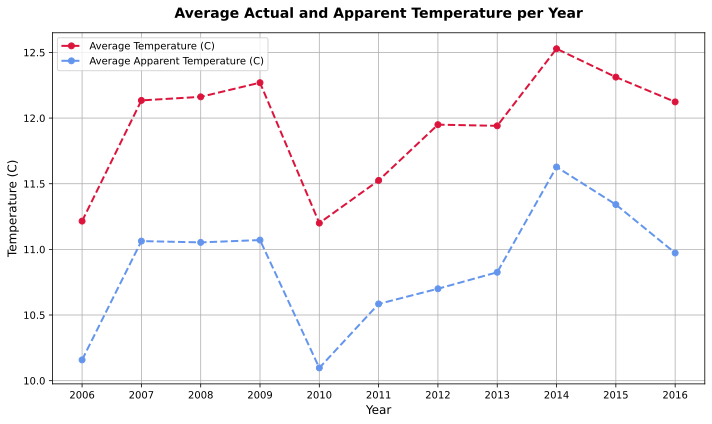

In [294]:
# Line graph showcasing temperature over time

fig, ax = plt.subplots(figsize=(10, 6))

yearly_avg = weather.groupby(weather['Formatted Date'].dt.year)[['Temperature (C)', 'Apparent Temperature (C)']].mean().reset_index()
yearly_avg = yearly_avg.drop(yearly_avg.index[0])

ax.plot(yearly_avg['Formatted Date'], yearly_avg['Temperature (C)'], 
        marker='o', 
        linestyle='--', 
        linewidth=2, 
        label='Average Temperature (C)',
        color='crimson')

ax.plot(yearly_avg['Formatted Date'], yearly_avg['Apparent Temperature (C)'], 
        marker='o', 
        linestyle='--', 
        linewidth=2, 
        label='Average Apparent Temperature (C)',
        color='cornflowerblue')

ax.set_xticks([year for year in yearly_avg['Formatted Date']])
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Temperature (C)', fontsize=12)
ax.set_title('Average Actual and Apparent Temperature per Year', fontsize=14, fontweight='bold', pad=15)


ax.set_axisbelow(True)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


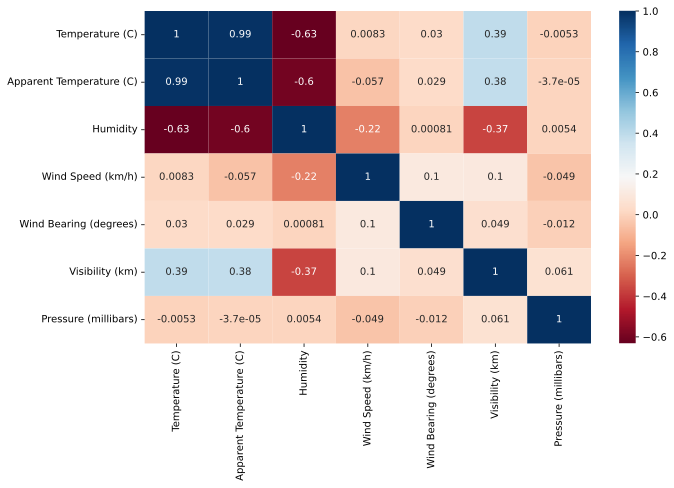

In [295]:
# Heatmap with all numeric values
fig, ax = plt.subplots(figsize=(10, 6))

numeric_weather = weather.select_dtypes(include='number')
ax = sns.heatmap(numeric_weather.corr(), annot=True, cmap='RdBu')

plt.show()

In [296]:
# Is there a relation between high temperature and humidity levels?

fig, ax = plt.subplots(figsize=(10, 6))

daily_temp_humidity = weather.groupby(weather['Formatted Date'].dt.to_period('D'))[['Temperature (C)', 'Humidity']].mean().reset_index()

scatter = ax.scatter(y=daily_temp_humidity['Temperature (C)'], x=daily_temp_humidity['Humidity'], 
            s=daily_temp_humidity['Humidity'] * 20,
            c=daily_temp_humidity['Humidity'], cmap='magma',
            alpha=0.7)

ax.set_xlabel('Humidity Level', fontsize=12, labelpad=10)
ax.set_ylabel('Temperature (C)', fontsize=12, labelpad=10)
ax.set_title('Temperature (C) vs. Humidity (Per Day)', fontsize=14, fontweight='bold', pad=15)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

cbar = fig.colorbar(scatter, ax=ax, label='Humidity Level')
cbar.ax.invert_yaxis()

plt.tight_layout()
plt.show()

/var/folders/30/kdmhqhbd2xb8d_qmfddlzx6h0000gn/T/ipykernel_46489/190444267.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  daily_temp_humidity = weather.groupby(weather['Formatted Date'].dt.to_period('D'))[['Temperature (C)', 'Humidity']].mean().reset_index()


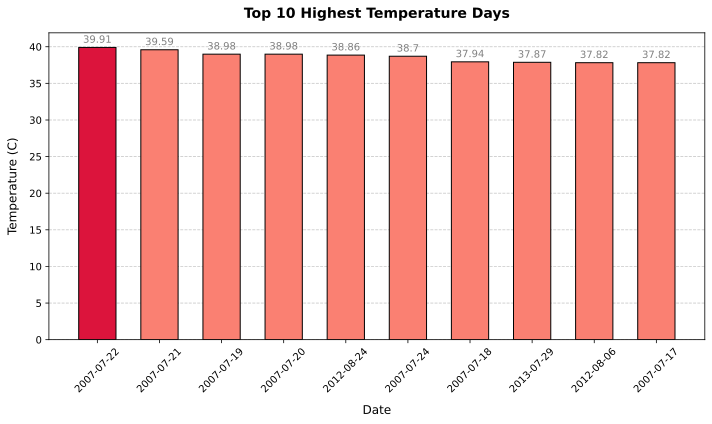

In [323]:
# Top 10 Highest Temperature Days
fig, ax = plt.subplots(figsize=(10, 6))

top_10_days = weather.groupby(weather['Formatted Date'].dt.date)['Temperature (C)'].max()

top_10_days = top_10_days.sort_values(ascending=False).head(10)

top_10_days.index = top_10_days.index.astype('str')

colors = ['crimson' if i == 0 else 'salmon' for i in range(0, 10)]

plt.bar(top_10_days.index, top_10_days.values, 
        edgecolor='black', width=0.6, color=colors)

for i in range(len(top_10_days)):
    ax.annotate(f'{round(top_10_days.values[i], 2)}', 
                xy=(top_10_days.index[i], (top_10_days.values[i] + 1)), 
                va='center', ha='center', color='Gray')
    

ax.set_title('Top 10 Highest Temperature Days', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12, labelpad=10)
ax.set_ylabel('Temperature (C)', fontsize=12, labelpad=10)

ax.set_axisbelow(True)
ax.yaxis.grid(linestyle='--', alpha=0.7)

ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


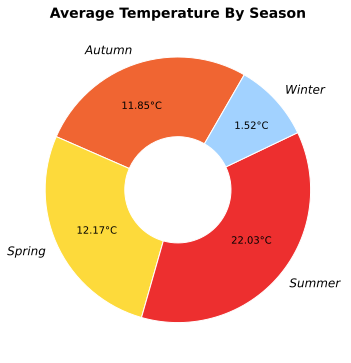

In [454]:
# Average temperature by season cycle chart 
#  spring = 3,4,5 summer = 6, 7, 8 autumn = 9, 10 , 11 winter= 12, 1 , 2

fig, ax = plt.subplots(figsize=(10, 6))

weather['season'] = pd.cut(weather['Formatted Date'].dt.month, 
                           bins=[0, 2, 5, 8, 11, np.inf],
                           labels=['Winter', 'Spring', 'Summer', 'Autumn', 'Winter'], 
                           ordered=False).astype('category')

season_temp = weather.groupby('season')['Temperature (C)'].mean()

colors = ['#f06532', '#fdda3b', '#ed2f2f', '#a2d2ff']

ax.pie(x=list(np.sqrt(season_temp.values)), labels=list(season_temp.index), colors=colors,
       startangle=60, 
       wedgeprops=dict(width=0.6, edgecolor='white', linewidth=1),
       textprops={'fontsize': 12, 'fontstyle': 'italic', 'color': 'black'})


ax.annotate(f'{round(season_temp.values[0], 2)}°C', 
              xy=(130, 250), xycoords='axes pixels',
              va='center', ha='center', color='Black')

ax.annotate(f'{round(season_temp.values[1], 2)}°C', 
              xy=(85, 125), xycoords='axes pixels',
              va='center', ha='center', color='Black')

ax.annotate(f'{round(season_temp.values[2], 2)}°C', 
              xy=(240, 115), xycoords='axes pixels',
              va='center', ha='center', color='Black')

ax.annotate(f'{round(season_temp.values[3], 2)}°C', 
              xy=(240, 230), xycoords='axes pixels',
              va='center', ha='center', color='Black')

ax.set_title('Average Temperature By Season', loc='center', fontsize=14, fontweight='bold')
plt.tight_layout
plt.show()

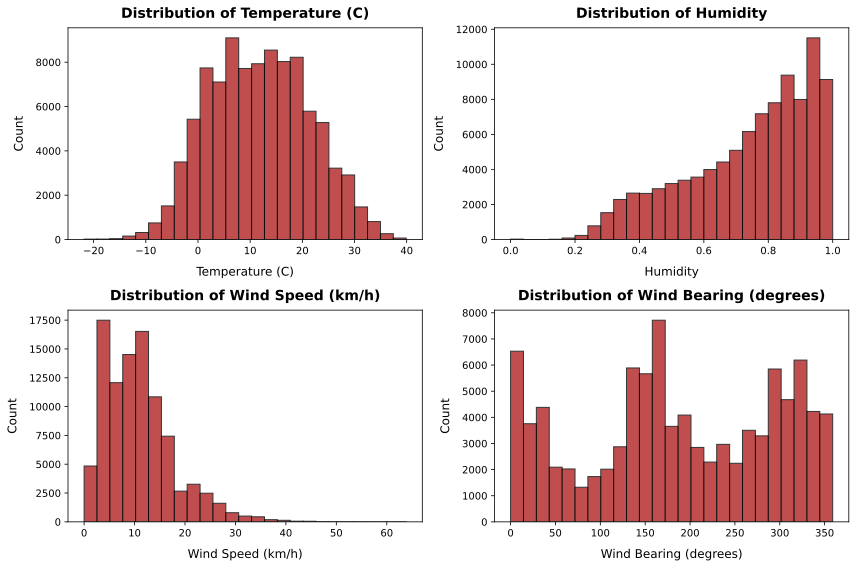

In [497]:
# Distribution of Temperature, Humidity, Wind Speed, and Wind Bearing
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0][0].hist(weather['Temperature (C)'], bins=25, edgecolor='black', alpha=0.8, color='firebrick')
ax[0][0].set_title('Distribution of Temperature (C)', fontweight='bold', fontsize=14, pad=10)
ax[0][0].set_xlabel('Temperature (C)', fontsize=12, labelpad=10)
ax[0][0].set_ylabel('Count', fontsize=12, labelpad=10)

ax[0][1].hist(weather['Humidity'], bins=25, edgecolor='black', alpha=0.8, color='firebrick')
ax[0][1].set_title('Distribution of Humidity', fontweight='bold', fontsize=14, pad=10)
ax[0][1].set_xlabel('Humidity', fontsize=12, labelpad=10)
ax[0][1].set_ylabel('Count', fontsize=12, labelpad=10)

ax[1][0].hist(weather['Wind Speed (km/h)'], bins=25, edgecolor='black', alpha=0.8, color='firebrick')
ax[1][0].set_title('Distribution of Wind Speed (km/h)', fontweight='bold', fontsize=14, pad=10)
ax[1][0].set_xlabel('Wind Speed (km/h)', fontsize=12, labelpad=10)
ax[1][0].set_ylabel('Count', fontsize=12, labelpad=10)

ax[1][1].hist(weather['Wind Bearing (degrees)'], bins=25, edgecolor='black', alpha=0.8, color='firebrick')
ax[1][1].set_title('Distribution of Wind Bearing (degrees)', fontweight='bold', fontsize=14, pad=10)
ax[1][1].set_xlabel('Wind Bearing (degrees)', fontsize=12, labelpad=10)
ax[1][1].set_ylabel('Count', fontsize=12, labelpad=10)


plt.tight_layout()
plt.show()